# Setup


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from scipy.stats import zscore
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, f1_score
)

from imblearn.over_sampling import SMOTE

import joblib

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("fraud.csv")

In [3]:
print(df.shape)

(102723, 10)


In [4]:
df.head()

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0.0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0.0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0.0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0.0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102723 entries, 0 to 102722
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         102723 non-null  int64  
 1   customer     102723 non-null  object 
 2   age          102723 non-null  object 
 3   gender       102723 non-null  object 
 4   zipcodeOri   102723 non-null  object 
 5   merchant     102723 non-null  object 
 6   zipMerchant  102723 non-null  object 
 7   category     102723 non-null  object 
 8   amount       102722 non-null  float64
 9   fraud        102722 non-null  float64
dtypes: float64(2), int64(1), object(7)
memory usage: 7.8+ MB


# Data Preprocessing

In [6]:
str_cols = df.select_dtypes(include="object").columns
for c in str_cols:
    df[c] = df[c].str.strip("'")

In [7]:
print("zipcodeOri unique:", df["zipcodeOri"].nunique())
print("zipMerchant unique:", df["zipMerchant"].nunique())

zipcodeOri unique: 1
zipMerchant unique: 1


In [8]:
df = df.drop(columns=["zipcodeOri", "zipMerchant"])

## Missing data

In [9]:
df.isnull().sum()

,0
step,0
customer,0
age,0
gender,0
merchant,0
category,0
amount,1
fraud,1


No missing data is found in the dataset so analysis will proceed

In [10]:
print(sorted(df["age"].unique()))
print(sorted(df["gender"].unique()))
print(df["category"].nunique(), "categories")

['0', '1', '2', '3', '4', '5', '6', 'U']
['E', 'F', 'M', 'U']
16 categories


In [11]:
df.head()

,step,customer,age,gender,merchant,category,amount,fraud
0,0,C1093826151,4,M,M348934600,es_transportation,4.55,0.0
1,0,C352968107,2,M,M348934600,es_transportation,39.68,0.0
2,0,C2054744914,4,F,M1823072687,es_transportation,26.89,0.0
3,0,C1760612790,3,M,M348934600,es_transportation,17.25,0.0
4,0,C757503768,5,M,M348934600,es_transportation,35.72,0.0


feature and target split will be done after feature engineering to ensure all relevant variables are captured

# Exploratory Data Analysis (EDA)

### Class Imbalance

In [12]:
rate_fraud = df["fraud"].mean()
print(rate_fraud)

0.014680399524931368


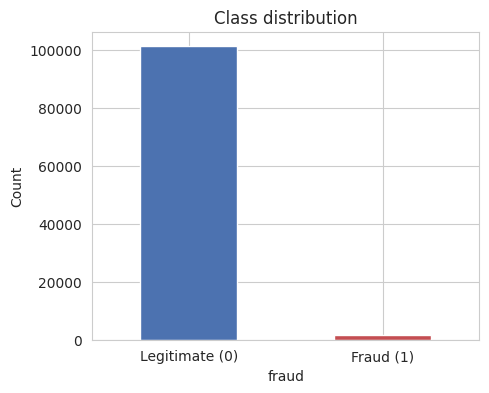

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
df["fraud"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"], rotation=0)
ax.set_title("Class distribution")
ax.set_ylabel("Count")
plt.show()

we can clearly see an imbalance in class distribution, this proves that accuracy cannot be used as the metric for evaluating any classification models

### Fraud by category

In [14]:
cat_fraud = (
    df.groupby("category")["fraud"]
    .agg(fraud_rate="mean", n="count")
    .sort_values("fraud_rate", ascending=False)
)
cat_fraud

,fraud_rate,n
category,,
es_leisure,0.945736,129
es_travel,0.715084,179
es_sportsandtoys,0.421675,1015
es_hotelservices,0.217523,331
es_otherservices,0.163636,330
es_home,0.156566,396
es_health,0.150811,2281
es_tech,0.070093,428
es_wellnessandbeauty,0.056398,2837


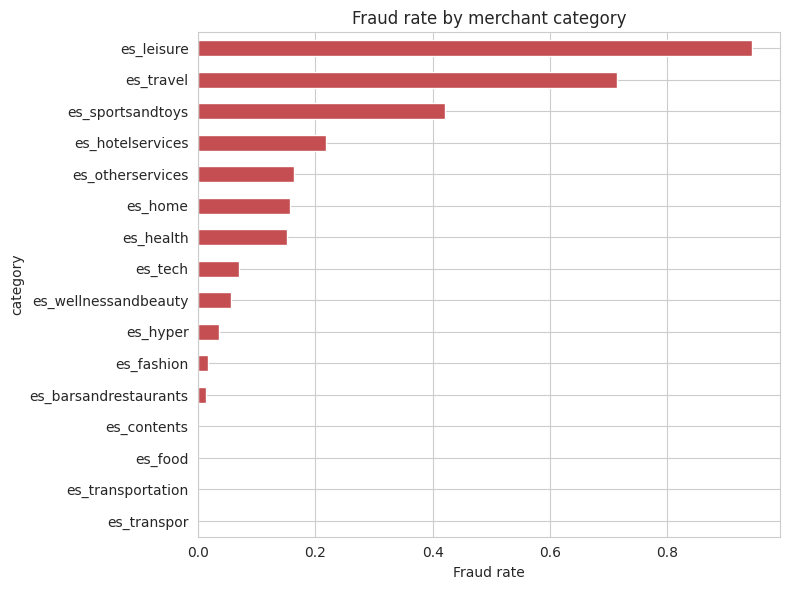

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
cat_fraud["fraud_rate"].plot(kind="barh", ax=ax, color="#C44E52")
ax.set_xlabel("Fraud rate")
ax.set_title("Fraud rate by merchant category")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Transaction amount vs fraud

In [16]:
df.groupby("fraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
fraud,,,,,,,,
0.0,101214.0,31.942522,33.672413,0.00,13.6100,26.59,42.0475,2144.86
1.0,1508.0,554.087175,875.068881,1.83,155.5625,325.62,559.6325,7432.48


/tmp/ipykernel_660/2535381738.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Legitimate", "Fraud"])


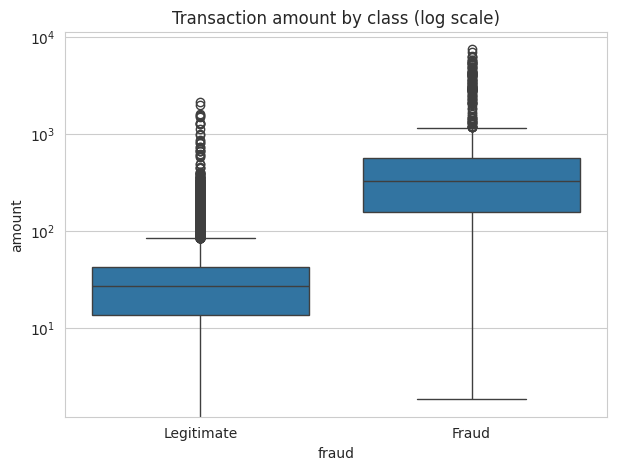

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="fraud", y="amount", ax=ax)
ax.set_yscale("log")
ax.set_xticklabels(["Legitimate", "Fraud"])
ax.set_title("Transaction amount by class (log scale)")
plt.show()


In [18]:
Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["amount"] < lower_bound) | (df["amount"] > upper_bound)]
print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(df):.2%} of data)")

# How much do outliers overlap with fraud?
print(outliers["fraud"].value_counts(normalize=True))

Number of outliers: 4648 (4.52% of data)
fraud
0.0    0.718589
1.0    0.281411
Name: proportion, dtype: float64


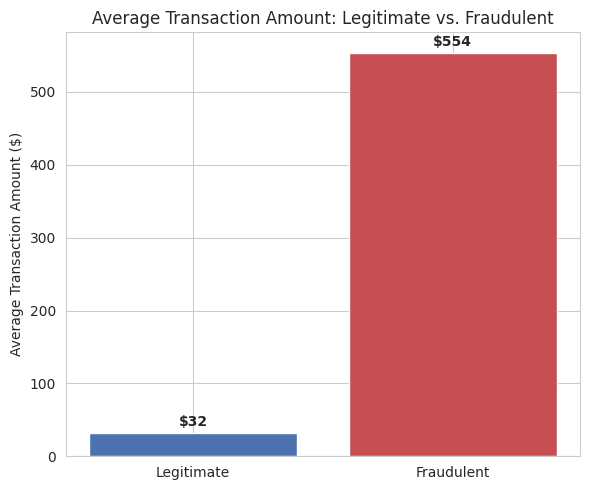

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
amounts = df.groupby("fraud")["amount"].mean()
bars = ax.bar(["Legitimate", "Fraudulent"], [amounts[0], amounts[1]], color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Average Transaction Amount ($)")
ax.set_title("Average Transaction Amount: Legitimate vs. Fraudulent")

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"${height:.0f}", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 5), textcoords="offset points", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("avg_amount_comparison.png", dpi=200)
plt.show()

The presence of outliers here serves as a signal instead of noise, as it is clearly observed that the median transaction amount for fraud cases are significantly higher than those of legitimate transactions and therefore I decided to not remove any outliers as the model would need them to learn from these points.

## Age and Gender Breakdown

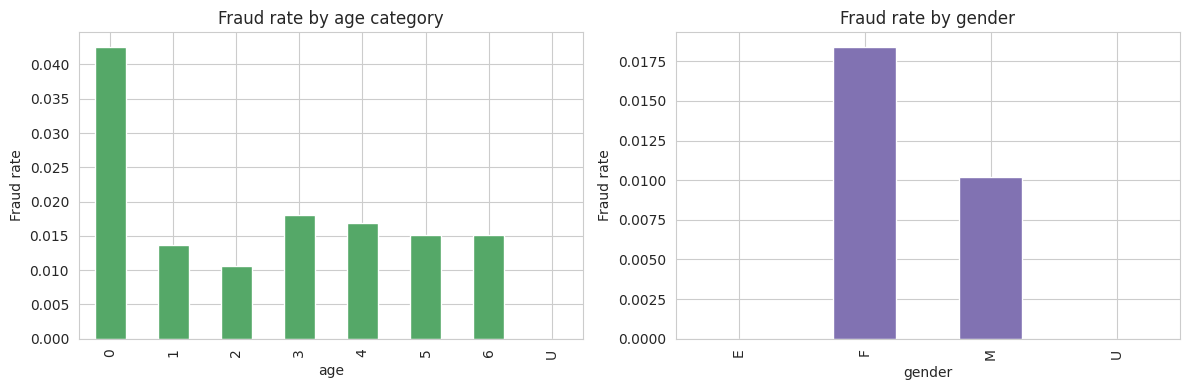

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby("age")["fraud"].mean().sort_index().plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].set_title("Fraud rate by age category")
axes[0].set_ylabel("Fraud rate")

df.groupby("gender")["fraud"].mean().plot(kind="bar", ax=axes[1], color="#8172B2")
axes[1].set_title("Fraud rate by gender")
axes[1].set_ylabel("Fraud rate")

plt.tight_layout()
plt.show()

In [20]:
from scipy.stats import chi2_contingency

age_ct = pd.crosstab(df["age"], df["fraud"])
chi2_age, p_age, dof_age, expected_age = chi2_contingency(age_ct)
print(f"Age vs Fraud — chi2={chi2_age:.2f}, p={p_age:.4g}, dof={dof_age}")

gender_ct = pd.crosstab(df["gender"], df["fraud"])
chi2_gender, p_gender, dof_gender, expected_gender = chi2_contingency(gender_ct)
print(f"Gender vs Fraud — chi2={chi2_gender:.2f}, p={p_gender:.4g}, dof={dof_gender}")

Age vs Fraud — chi2=86.55, p=6.313e-16, dof=7
Gender vs Fraud — chi2=121.31, p=4.037e-26, dof=3


In [21]:
def cramers_v(chi2, contingency_table):
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return (chi2 / (n * (min(r, k) - 1))) ** 0.5

print("Cramér's V (age):", cramers_v(chi2_age, age_ct))
print("Cramér's V (gender):", cramers_v(chi2_gender, gender_ct))

Cramér's V (age): 0.02902692564231405
Cramér's V (gender): 0.03436451794076305


From the graph above, age buckets show a nearly flat fraud rate between them, with the youngest group slightly higher than the rest and the unknown age group being the lowest. However, this is a weak signal

In terms of Gender, the graph shows that Female customers have a higher fraud rate than male, but its also clear that this is not a primary driver of fraud in this dataset.

This is confirmed by the statistic test conducted after applying effect size (Cramer's V test) where the test statistic value indicates that for both age and gender, the effect on fraud is negligible.

## Transaction volume over time

In [22]:
df.groupby("step")["fraud"].sum().describe()

,fraud
count,38.000000
mean,39.684211
std,1.946657
min,28.000000
25%,40.000000
50%,40.000000
75%,40.000000
max,40.000000


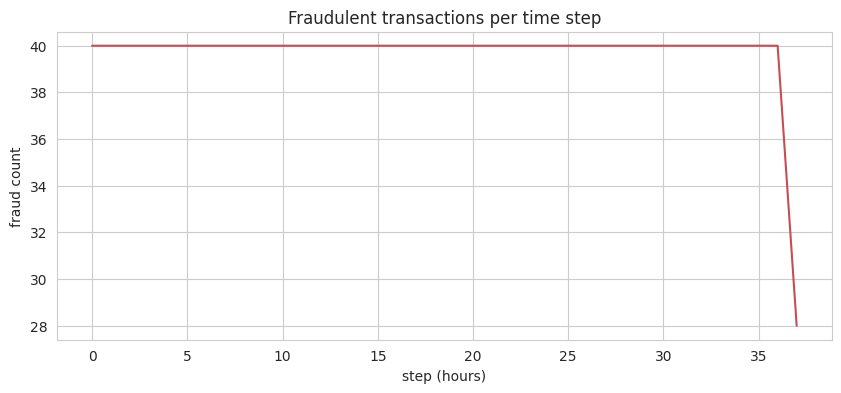

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
df.groupby("step")["fraud"].sum().plot(ax=ax, color="#C44E52")
ax.set_title("Fraudulent transactions per time step")
ax.set_xlabel("step (hours)")
ax.set_ylabel("fraud count")
plt.show()


### Correlation Matrix

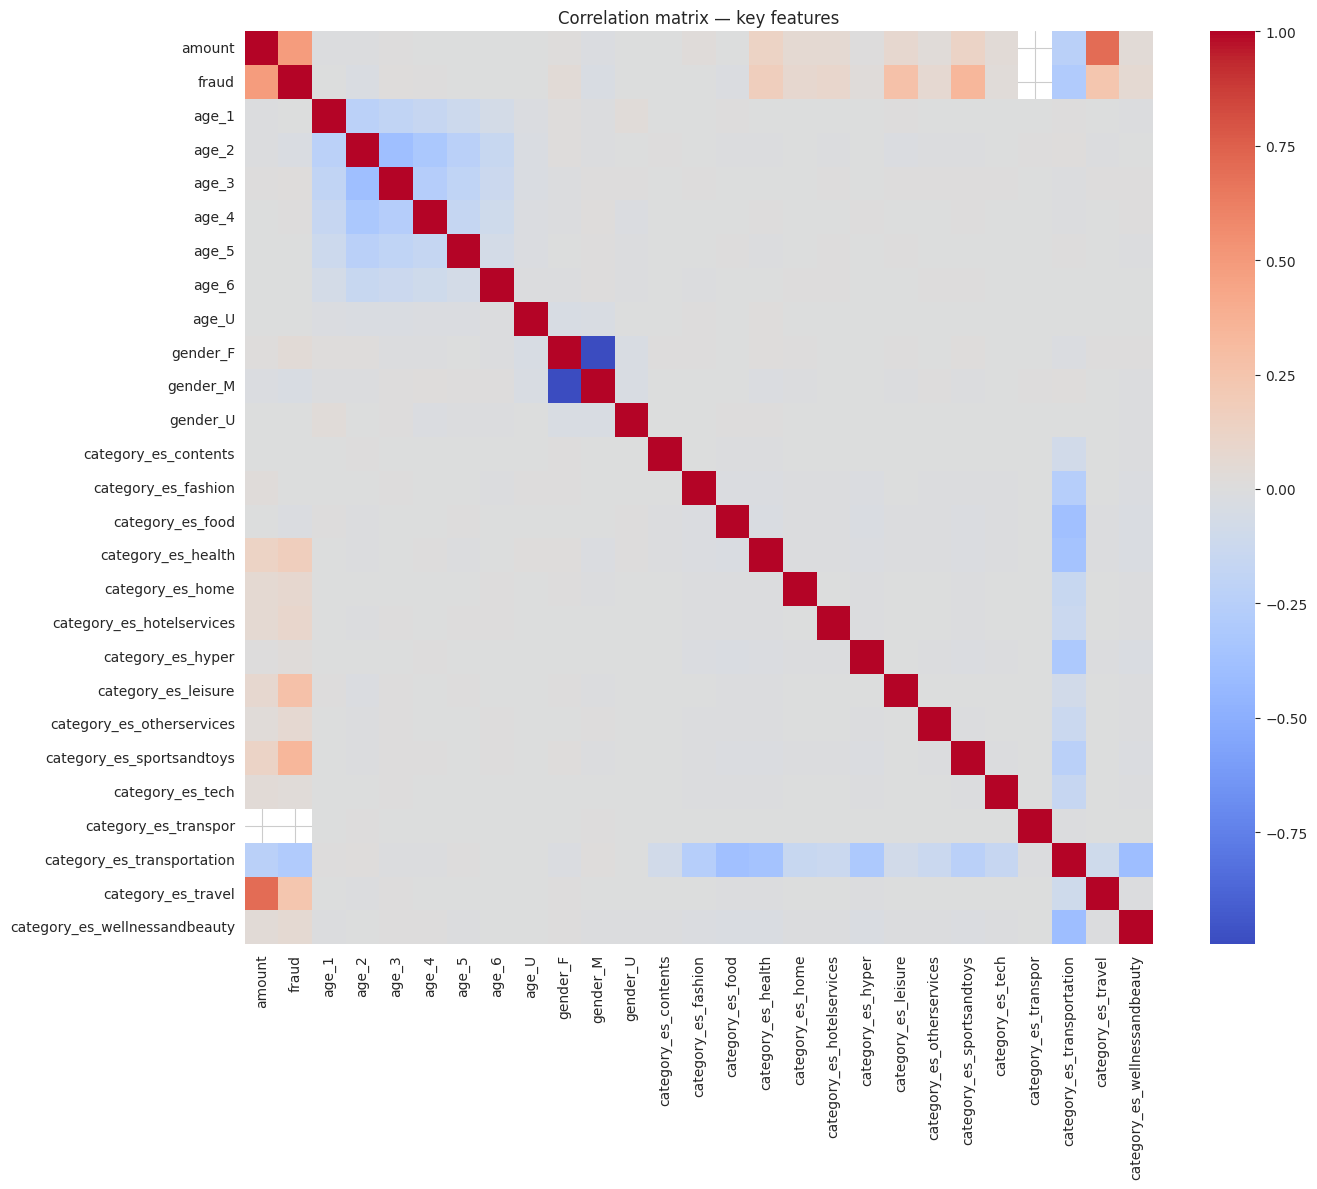

,fraud
amount,0.491953
category_es_sportsandtoys,0.338056
category_es_transportation,-0.289201
category_es_leisure,0.274508
category_es_travel,0.243312
category_es_health,0.170571
category_es_hotelservices,0.095892
category_es_home,0.073390
category_es_otherservices,0.070311
category_es_wellnessandbeauty,0.058457


In [24]:
corr_df = pd.get_dummies(
    df[["amount", "age", "gender", "category", "fraud"]],
    columns=["age", "gender", "category"],
    drop_first=True
)

corr = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlation matrix — key features")
plt.tight_layout()
plt.show()

# Focused view: correlation of each feature with the fraud target, sorted
fraud_corr = corr["fraud"].drop("fraud").sort_values(key=abs, ascending=False)
fraud_corr.head(15)

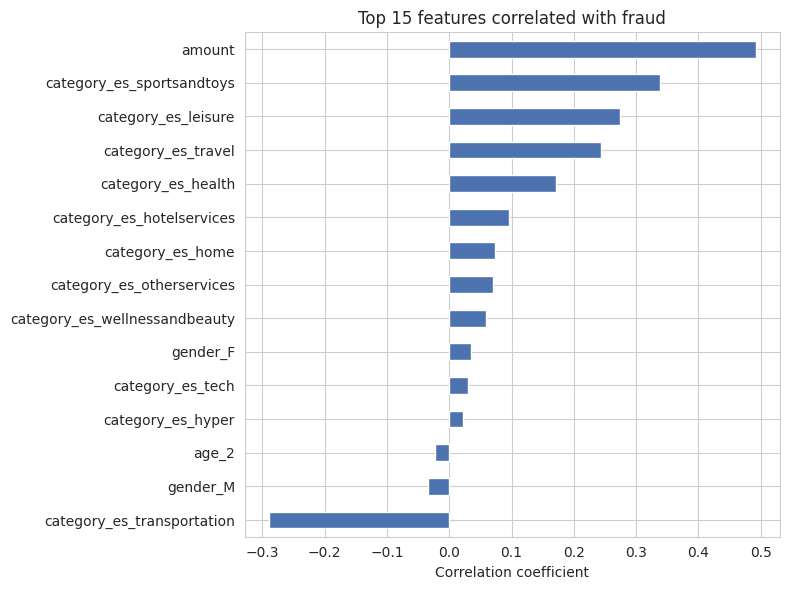

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
fraud_corr.head(15).sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Top 15 features correlated with fraud")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

# Feature Engineering

In [26]:
df["hour_of_day"] = df["step"] % 24

def time_bucket(h):
    if 0 <= h < 6:
        return "night"
    elif 6 <= h < 12:
        return "morning"
    elif 12 <= h < 18:
        return "afternoon"
    else:
        return "evening"

df["time_bucket"] = df["hour_of_day"].apply(time_bucket)
df[["step", "hour_of_day", "time_bucket"]].head()


,step,hour_of_day,time_bucket
0,0,0,night
1,0,0,night
2,0,0,night
3,0,0,night
4,0,0,night


In [27]:
customer_stats = df.groupby("customer")["amount"].agg(
    customer_avg_amount="mean",
    customer_txn_count="count"
)
df = df.merge(customer_stats, on="customer", how="left")
df[["customer", "customer_avg_amount", "customer_txn_count"]].head()


,customer,customer_avg_amount,customer_txn_count
0,C1093826151,28.240719,167
1,C352968107,32.661361,169
2,C2054744914,41.443692,65
3,C1760612790,30.338772,171
4,C757503768,31.696759,145


In [28]:
# Drop high-cardinality ID columns that aren't useful as raw categorical features
df_model = df.drop(columns=["customer", "merchant", "step", "hour_of_day"])

# One-hot encode categoricals
df_model = pd.get_dummies(df_model, columns=["age", "gender", "category", "time_bucket"], drop_first=True)

print(df_model.shape)
df_model.head()


(594643, 31)


,amount,fraud,customer_avg_amount,customer_txn_count,age_1,age_2,age_3,age_4,age_5,age_6,age_U,gender_F,gender_M,gender_U,category_es_contents,category_es_fashion,category_es_food,category_es_health,category_es_home,category_es_hotelservices,category_es_hyper,category_es_leisure,category_es_otherservices,category_es_sportsandtoys,category_es_tech,category_es_transportation,category_es_travel,category_es_wellnessandbeauty,time_bucket_evening,time_bucket_morning,time_bucket_night
0,4.55,0,28.240719,167,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True
1,39.68,0,32.661361,169,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True
2,26.89,0,41.443692,65,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True
3,17.25,0,30.338772,171,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True
4,35.72,0,31.696759,145,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True


# Train/Test Split


In [29]:
#Defining the feature and target variables
X = df_model.drop(columns=["fraud"])
y = df_model["fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())


Train fraud rate: 0.012108115380249477
Test fraud rate: 0.012108064475443332


In [48]:
# Scale the numeric features
numeric_cols = ["amount", "customer_avg_amount", "customer_txn_count"]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


# Handling Class Imbalance

In [31]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_res.value_counts().to_dict())


Before SMOTE: {0: 469954, 1: 5760}
After SMOTE:  {0: 469954, 1: 469954}


Here, synthetic generation was used to handle the class imbalance issue, it was only applied to the training set as to avoid data leakage and to have a realistic test set

# Model Training

In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    fitted_models[name] = model
    print(f"Trained: {name}")


Trained: Logistic Regression
Trained: Random Forest
Trained: Gradient Boosting


# Model Evaluation

In [33]:
results = []

for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    auc_roc = roc_auc_score(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)

    results.append({
        "model": name,
        "precision (fraud)": report["1"]["precision"],
        "recall (fraud)": report["1"]["recall"],
        "f1 (fraud)": report["1"]["f1-score"],
        "AUC-ROC": auc_roc,
        "AUC-PR": auc_pr,
    })

results_df = pd.DataFrame(results).sort_values("AUC-PR", ascending=False)
results_df


,model,precision (fraud),recall (fraud),f1 (fraud),AUC-ROC,AUC-PR
2,Gradient Boosting,0.277246,0.964583,0.430698,0.996275,0.867375
1,Random Forest,0.626653,0.855556,0.723429,0.994625,0.826288
0,Logistic Regression,0.273201,0.946528,0.424016,0.994580,0.821233


Gradient Boosting has the highest AUC-PR (0.867) and highest recall (96.5%), but it has low precision (27.7%)

Random Forest has lower recall (85.6%) but much higher precision (62.7%) and the best F1-score out of all the models.(0.723).

This is a genuine business trade-off: Gradient Boosting minimizes missed fraud
at the cost of more false alarms, while Random Forest minimizes false alarms at the cost
of missing more fraud. Gradient Boosting is carried forward here based on AUC-PR, the
metric best suited to this level of class imbalance.

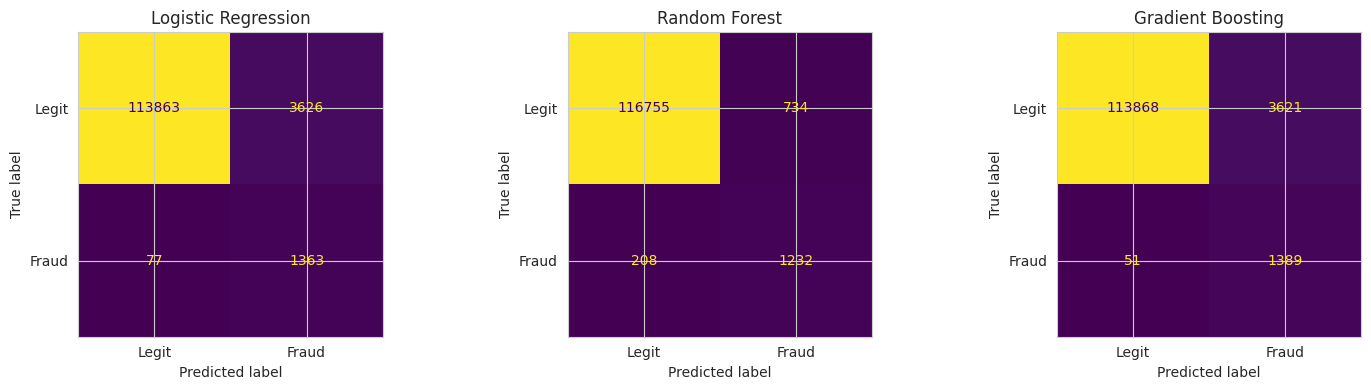

In [34]:
# Confusion matrices for each model
fig, axes = plt.subplots(1, len(fitted_models), figsize=(5 * len(fitted_models), 4))
for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


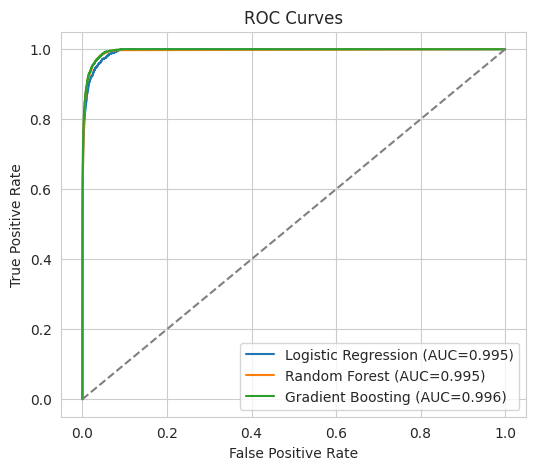

In [35]:
# ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_proba):.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend()
plt.show()


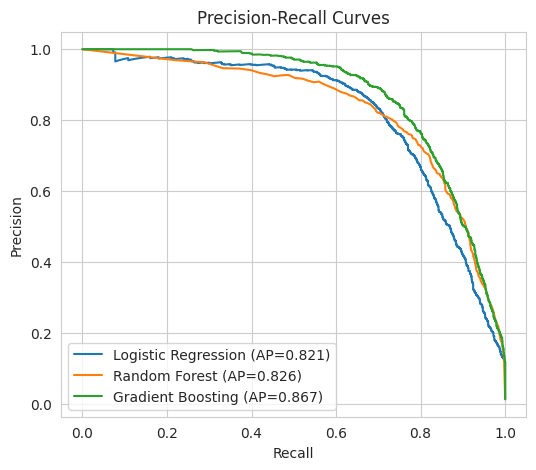

In [36]:
# Precision-Recall curves
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ax.plot(recall, precision, label=f"{name} (AP={average_precision_score(y_test, y_proba):.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves")
ax.legend()
plt.show()


This graph confirms that the gradient boosting model has the best precision/recall trade-off across all thresholds. Therefore, it will be selected as the final model to be tuned and used for predicting fraud in this case.

# Model Interpretation

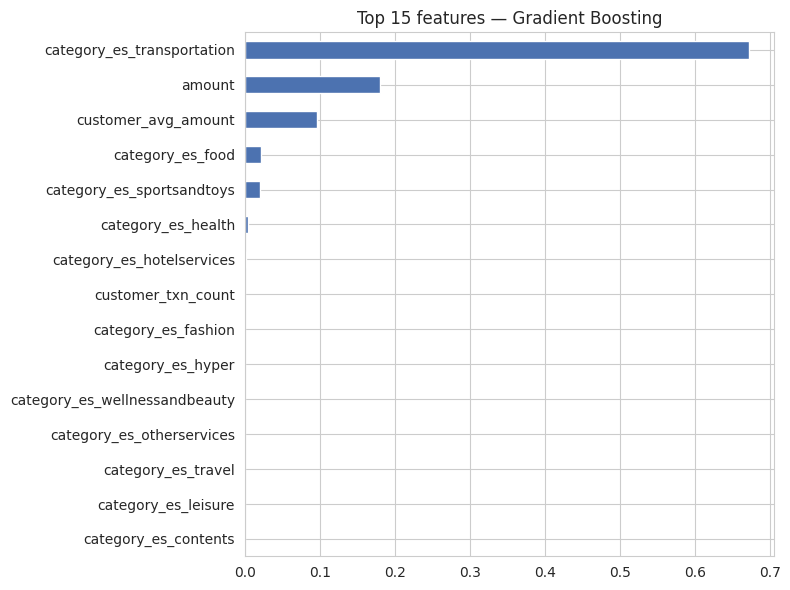

In [38]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
elif hasattr(best_model, "coef_"):
    importances = pd.Series(best_model.coef_[0], index=X_train.columns).abs()
else:
    importances = None

if importances is not None:
    top_features = importances.sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(8, 6))
    top_features.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_title(f"Top 15 features — {best_model_name}")
    plt.tight_layout()
    plt.show()


The model's top feature is category_es_transportation (importance ≈ 0.67), followed by
amount (≈ 0.18) and customer_avg_amount (≈ 0.09). This confirms the EDA finding that
transportation is a strongly safe category (0% fraud), but with an important nuance:
feature importance reflects how much a split reduces prediction error, not which class
it favors. Because transportation makes up 85% of all transactions and is never
fraudulent, the model leans on it heavily as a high-confidence signal for ruling
transactions OUT as fraud. By contrast, es_leisure and es_travel, the categories with
the highest fraud rates in the EDA contribute comparatively little importance despite
being highly predictive when they occur, simply because they're rare (under 0.2% of
transactions combined). Amount remains an independent, strong signal consistent with
its 0.49 correlation with fraud observed earlier.

# Hyperparameter tuning


In [39]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import resample

X_tune, y_tune = resample(
    X_train_res, y_train_res,
    n_samples=200_000,
    random_state=RANDOM_STATE,
    stratify=y_train_res
)

print("Tuning subsample size:", X_tune.shape)
print("Tuning subsample fraud rate:", y_tune.mean())

Tuning subsample size: (200000, 30)
Tuning subsample fraud rate: 0.5


In [40]:
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "penalty": ["l2"],
    },
    "Random Forest": {
        "n_estimators": [200, 400],
        "max_depth": [None, 10, 20],
        "min_samples_leaf": [1, 5],
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3],
    },
}

base_model = models[best_model_name].__class__(random_state=RANDOM_STATE) if best_model_name != "Logistic Regression" \
    else LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    base_model,
    param_grids[best_model_name],
    n_iter=8,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2,
)

random_search.fit(X_tune, y_tune)

print("Best params:", random_search.best_params_)
print("Best CV AUC-PR (on subsample):", random_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
Best CV AUC-PR (on subsample): 0.998043930563413


In [41]:
tuned_model = base_model.__class__(**random_search.best_params_, random_state=RANDOM_STATE)
tuned_model.fit(X_train_res, y_train_res)

y_pred_tuned = tuned_model.predict(X_test)
y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_tuned))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_tuned))
print("AUC-PR: ", average_precision_score(y_test, y_proba_tuned))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99    117489
           1       0.30      0.96      0.46      1440

    accuracy                           0.97    118929
   macro avg       0.65      0.97      0.72    118929
weighted avg       0.99      0.97      0.98    118929

AUC-ROC: 0.9963288407141662
AUC-PR:  0.8712540042449812


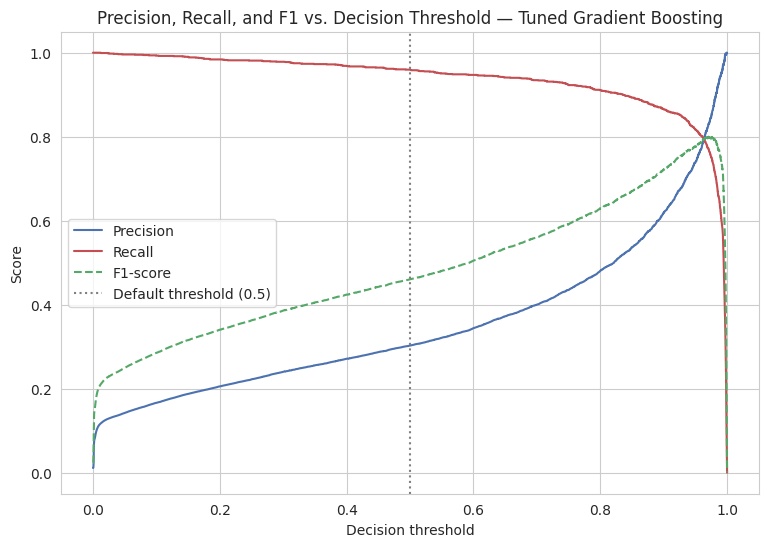

In [46]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_tuned)

precisions_aligned = precisions[:-1]
recalls_aligned = recalls[:-1]
f1_scores = 2 * (precisions_aligned * recalls_aligned) / (precisions_aligned + recalls_aligned + 1e-10)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(thresholds, precisions_aligned, label="Precision", color="#4C72B0")
ax.plot(thresholds, recalls_aligned, label="Recall", color="#C44E52")
ax.plot(thresholds, f1_scores, label="F1-score", color="#55A868", linestyle="--")
ax.axvline(0.5, color="grey", linestyle=":", label="Default threshold (0.5)")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Precision, Recall, and F1 vs. Decision Threshold — Tuned Gradient Boosting")
ax.legend()
plt.show()

The tuned model achieves AUC-PR of 0.871 and AUC-ROC of 0.996 on the held-out test set,
with 96% recall and 30% precision on the fraud class. In practical terms: this model
would catch the vast majority of fraudulent transactions, at the cost of also flagging a
meaningful number of legitimate ones for review, which is an acceptable trade-off if manual
review is cheap relative to the cost of missed fraud, and the basis for the business
recommendation to pair this model with a human review step rather than fully automated
blocking.

# Saving/downloading the model

In [42]:
import joblib

joblib.dump(tuned_model, "fraud_detection_model.pkl")
joblib.dump(scaler, "fraud_detection_scaler.pkl")
print("Saved model and scaler.")

Saved model and scaler.
